## Settings

In [1]:
import os, sys
import pandas as pd
from pathlib import Path
from dotenv import load_dotenv

sys.path.append(os.path.abspath('../../..'))
load_dotenv(os.path.join('../../..', '.env'))

os.environ['GRAPHRAG_API_KEY'] = os.environ.get('GEMINI_API_KEY', '')

QUESTION_TYPE = "global"          # local | global | multihop | comparative | negative
N_LIBROS      = 10
MAX_Q         = None
SHUFFLE       = False
RESULTS_DIR   = Path("./results")
RESULTS_DIR.mkdir(exist_ok=True)
DOMINIO = "cs"

In [2]:
DB_RAG = "../../../chroma_db_eval_traditional"
DB_RAGPlusPlus = "../../../chroma_db_RAGPlusPlus"
DB_LightRAG = "../../../lightrag_eval"
DB_PropertyRAG = ""
DB_MSGraphRAG = "../../../ms_graphrag_workspace"

In [3]:
from src.evaluation.experiment import run_local_experiment

PATH_PREGUNTAS = "./qa/globalQA.json"
PATH_RESULTADOS = "./results/"

/Volumes/Toni 1TB/MESIIA/TFM/TFM_Repositori/Code_TFM/venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Volumes/Toni 1TB/MESIIA/TFM/TFM_Repositori/Code_TFM/venv/lib/python3.10/site-packages/instructor/providers/gemini/client.py:6: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


## Traditional RAG

In [4]:
from src.baselines.traditional_rag import TraditionalRAG

rag = TraditionalRAG(persist_directory=DB_RAG)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Cargando índice existente desde ../../../chroma_db_eval_traditional...


In [5]:
resultado = await run_local_experiment(
    rag_type="traditional",
    rag_object=rag,
    questions_path=PATH_PREGUNTAS,
    save_path=PATH_RESULTADOS,
    nombre_experimento="Test_Global_01"
)


🔍 Evaluando TRADITIONAL | Test_Global_01 | 20 preguntas
────────────────────────────────────────────────────────────
  [1/20] Which of the 10 books deals primarily with low-level operating system ...
  [2/20] How many of the 10 books are focused specifically on a Microsoft techn...
  [3/20] Which books in the collection target an undergraduate or introductory ...
  [4/20] Which book in the collection has the most questions associated with it...
  [5/20] Which two books in the collection share a focus on database query lang...
  [6/20] What is the common programming paradigm shared by the Java and VBA boo...
  [7/20] Which book in the collection is most focused on mathematical theory ra...
  [8/20] Which books in the collection use R as their primary programming langu...
  [9/20] Which book in the collection deals with distributed computing and big ...
  [10/20] What mathematical discipline forms the theoretical foundation shared b...
  [11/20] Which books in the collection would be mo

## RAG++

In [4]:
from src.baselines.advanced_rag import AdvancedRAG

rag_advanced = AdvancedRAG(persist_directory=DB_RAGPlusPlus)
rag_advanced.load_existing_index() 

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


   Docs recuperados de Chroma: 11824
   _all_docs construidos: 11824


In [8]:
resultado = await run_local_experiment(
    rag_type="advanced",
    rag_object=rag_advanced,
    questions_path=PATH_PREGUNTAS,
    save_path=PATH_RESULTADOS,
    nombre_experimento="Test_Global_01"
)


🔍 Evaluando ADVANCED | Test_Global_01 | 20 preguntas
────────────────────────────────────────────────────────────
  [1/20] Which of the 10 books deals primarily with low-level operating system ...
  [2/20] How many of the 10 books are focused specifically on a Microsoft techn...
  [3/20] Which books in the collection target an undergraduate or introductory ...
  [4/20] Which book in the collection has the most questions associated with it...
  [5/20] Which two books in the collection share a focus on database query lang...
  [6/20] What is the common programming paradigm shared by the Java and VBA boo...
  [7/20] Which book in the collection is most focused on mathematical theory ra...
  [8/20] Which books in the collection use R as their primary programming langu...
  [9/20] Which book in the collection deals with distributed computing and big ...
  [10/20] What mathematical discipline forms the theoretical foundation shared b...
  [11/20] Which books in the collection would be most 

## LightRAG

In [6]:
from src.baselines.lightrag_rag import build_lightrag

rag_light, tracker = await build_lightrag(
    workspace_dir=DB_LightRAG,
    clean=False,
)

INFO: [] Loaded graph from ../../../lightrag_eval/graph_chunk_entity_relation.graphml with 54773 nodes, 72142 edges
INFO:nano-vectordb:Load (54773, 3072) data
INFO:nano-vectordb:Init {'embedding_dim': 3072, 'metric': 'cosine', 'storage_file': '../../../lightrag_eval/vdb_entities.json'} 54773 data
INFO:nano-vectordb:Load (72142, 3072) data
INFO:nano-vectordb:Init {'embedding_dim': 3072, 'metric': 'cosine', 'storage_file': '../../../lightrag_eval/vdb_relationships.json'} 72142 data
INFO:nano-vectordb:Load (3712, 3072) data
INFO:nano-vectordb:Init {'embedding_dim': 3072, 'metric': 'cosine', 'storage_file': '../../../lightrag_eval/vdb_chunks.json'} 3712 data
INFO: [] Process 70981 KV load full_docs with 10 records
INFO: [] Process 70981 KV load text_chunks with 3712 records
INFO: [] Process 70981 KV load full_entities with 10 records
INFO: [] Process 70981 KV load full_relations with 10 records
INFO: [] Process 70981 KV load entity_chunks with 54773 records
INFO: [] Process 70981 KV load r

✅ LightRAG inicializado en: ../../../lightrag_eval
   max_async=12 | max_retries=10 | modelo=gemini-2.5-flash-lite
   chunk_size=600 | gleaning=0


In [7]:
resultado = await run_local_experiment(
    rag_type="lightrag",
    rag_object=rag_light,
    questions_path=PATH_PREGUNTAS,
    save_path=PATH_RESULTADOS,
    nombre_experimento="Test_Global_01"
)

INFO: LLM func: 12 new workers initialized (Timeouts: Func: 180s, Worker: 360s, Health Check: 375s)



🔍 Evaluando LIGHTRAG | Test_Global_01 | 20 preguntas
────────────────────────────────────────────────────────────
  [1/20] Which of the 10 books deals primarily with low-level operating system ...


INFO:  == LLM cache == saving: hybrid:keywords:25d33ff0103df50958db47e29f2bd793
INFO: Embedding func: 8 new workers initialized (Timeouts: Func: 30s, Worker: 60s, Health Check: 75s)
INFO: Query nodes: Low-level, 10 books, Operating system (top_k:40, cosine:0.2)
INFO: Local query: 40 entites, 140 relations
INFO: Query edges: Operating system internals, Application-level programming, Book recommendation (top_k:40, cosine:0.2)
INFO: Global query: 54 entites, 40 relations
INFO: Raw search results: 89 entities, 175 relations, 0 vector chunks
INFO: After truncation: 77 entities, 175 relations
INFO: Selecting 192 from 235 entity-related chunks by vector similarity
INFO: Find 13 additional chunks in 13 relations (deduplicated 87)
INFO: Selecting 13 from 13 relation-related chunks by vector similarity
INFO: Round-robin merged chunks: 205 -> 205 (deduplicated 0)
INFO: Final context: 77 entities, 175 relations, 20 chunks
INFO: Final chunks S+F/O: E7/1 R1/1 E10/2 R1/2 E1/3 R1/3 E1/4 R1/4 E2/5 R1/5

  [2/20] How many of the 10 books are focused specifically on a Microsoft techn...


INFO:  == LLM cache == saving: hybrid:keywords:dd0ccde1c9b6d4105799fd95bffb88e0
INFO: Query nodes: Microsoft products, Books, 10 books (top_k:40, cosine:0.2)
INFO: Local query: 40 entites, 438 relations
INFO: Query edges: Microsoft technology, Product focus, Book content (top_k:40, cosine:0.2)
INFO: Global query: 53 entites, 40 relations
INFO: Raw search results: 86 entities, 453 relations, 0 vector chunks
INFO: After truncation: 38 entities, 222 relations
INFO: Selecting 95 from 595 entity-related chunks by vector similarity
INFO: Find 92 additional chunks in 82 relations (deduplicated 41)
INFO: Selecting 92 from 92 relation-related chunks by vector similarity
INFO: Round-robin merged chunks: 187 -> 187 (deduplicated 0)
INFO: Final context: 38 entities, 222 relations, 20 chunks
INFO: Final chunks S+F/O: E4/1 R1/1 E3/2 R1/2 E2/3 R1/3 E1/4 R2/4 E2/5 R1/5 E2/6 R3/6 E1/7 R1/7 E2/8 R1/8 E3/9 R3/9 E2/10 R9/10
INFO:  == LLM cache == saving: hybrid:query:9a610d947ad31c25de707f0d1c473bf9


...

  RAGAS [5/20] Which two books in the collection share a focus on...
  RAGAS [6/20] What is the common programming paradigm shared by ...


INFO:openai._base_client:Retrying request to /chat/completions in 0.488548 seconds


  RAGAS [7/20] Which book in the collection is most focused on ma...
  RAGAS [8/20] Which books in the collection use R as their prima...
  RAGAS [9/20] Which book in the collection deals with distribute...
  RAGAS [10/20] What mathematical discipline forms the theoretical...
  RAGAS [11/20] Which books in the collection would be most releva...
  RAGAS [12/20] How many books in the collection are published as ...


INFO:openai._base_client:Retrying request to /chat/completions in 0.425705 seconds
INFO:openai._base_client:Retrying request to /chat/completions in 0.484106 seconds


  RAGAS [13/20] Which book in the collection is most focused on co...
  RAGAS [14/20] Which books in the collection cover metaprogrammin...
  RAGAS [15/20] Which author in the collection has also written a ...
  RAGAS [16/20] Which books in the collection explicitly target pr...
  RAGAS [17/20] What is the general programming language category ...
  RAGAS [18/20] Which book in the collection most directly connect...
  RAGAS [19/20] Which two books in the collection focus on optimiz...
  RAGAS [20/20] What is the predominant application domain of the ...

  💰 Tokens RAGAS:
     Total  : 165,237  (prompt: 148,505 | completion: 16,732)
     TPM    : 9,593 tokens/min
     RPM    : 8 requests/min  (140 requests en 17.23 min)
💾 Guardado en: ./results/lightrag_Test_Global_01_2026-04-30.json


## Property RAG

## MS_GraphRAG

In [4]:
from src.baselines.msgraphrag_rag import MSGraphRAG

ms_graph = MSGraphRAG(workspace_dir=DB_MSGraphRAG)
ms_graph.load()

📂 Cargando índice MS-GraphRAG...
   ✅ Entidades    : 31,159
   ✅ Relaciones   : 42,358
   ✅ Comunidades  : 4,612
   ✅ Reports      : 4,603
   ✅ Text units   : 1,867


In [7]:
resultado = await run_local_experiment(
    rag_type="msgraphrag_local",
    rag_object=ms_graph,
    questions_path=PATH_PREGUNTAS,
    save_path=PATH_RESULTADOS,
    nombre_experimento="Test_Global_01"
)


🔍 Evaluando MSGRAPHRAG_LOCAL | Test_Global_01 | 20 preguntas
────────────────────────────────────────────────────────────
  [1/20] Which of the 10 books deals primarily with low-level operating system ...
  [2/20] How many of the 10 books are focused specifically on a Microsoft techn...
  [3/20] Which books in the collection target an undergraduate or introductory ...
  [4/20] Which book in the collection has the most questions associated with it...


Traceback (most recent call last):
  File "/Volumes/Toni 1TB/MESIIA/TFM/TFM_Repositori/Code_TFM/venv/lib/python3.10/site-packages/litellm/llms/vertex_ai/gemini/vertex_and_google_ai_studio_gemini.py", line 1782, in make_call
    response = await client.post(api_base, headers=headers, data=data, stream=True, logging_obj=logging_obj)
  File "/Volumes/Toni 1TB/MESIIA/TFM/TFM_Repositori/Code_TFM/venv/lib/python3.10/site-packages/litellm/litellm_core_utils/logging_utils.py", line 190, in async_wrapper
    result = await func(*args, **kwargs)
  File "/Volumes/Toni 1TB/MESIIA/TFM/TFM_Repositori/Code_TFM/venv/lib/python3.10/site-packages/litellm/llms/custom_httpx/http_handler.py", line 403, in post
    raise e
  File "/Volumes/Toni 1TB/MESIIA/TFM/TFM_Repositori/Code_TFM/venv/lib/python3.10/site-packages/litellm/llms/custom_httpx/http_handler.py", line 359, in post
    response.raise_for_status()
  File "/Volumes/Toni 1TB/MESIIA/TFM/TFM_Repositori/Code_TFM/venv/lib/python3.10/site-packages/httpx

    ⚠️ Error: litellm.ServiceUnavailableError: litellm.MidStreamFallbackError: litellm.ServiceUnavailableError: Vertex_ai_betaException - b'{\n  "error": {\n    "code": 503,\n    "message": "This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.",\n    "status": "UNAVAILABLE"\n  }\n}\n' Original exception: ServiceUnavailableError: litellm.ServiceUnavailableError: Vertex_ai_betaException - b'{\n  "error": {\n    "code": 503,\n    "message": "This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.",\n    "status": "UNAVAILABLE"\n  }\n}\n'
  [5/20] Which two books in the collection share a focus on database query lang...
  [6/20] What is the common programming paradigm shared by the Java and VBA boo...
  [7/20] Which book in the collection is most focused on mathematical theory ra...
  [8/20] Which books in the collection use R as their primary programming langu...
  [9/20]

Traceback (most recent call last):
  File "/Volumes/Toni 1TB/MESIIA/TFM/TFM_Repositori/Code_TFM/venv/lib/python3.10/site-packages/litellm/llms/vertex_ai/gemini/vertex_and_google_ai_studio_gemini.py", line 1782, in make_call
    response = await client.post(api_base, headers=headers, data=data, stream=True, logging_obj=logging_obj)
  File "/Volumes/Toni 1TB/MESIIA/TFM/TFM_Repositori/Code_TFM/venv/lib/python3.10/site-packages/litellm/litellm_core_utils/logging_utils.py", line 190, in async_wrapper
    result = await func(*args, **kwargs)
  File "/Volumes/Toni 1TB/MESIIA/TFM/TFM_Repositori/Code_TFM/venv/lib/python3.10/site-packages/litellm/llms/custom_httpx/http_handler.py", line 403, in post
    raise e
  File "/Volumes/Toni 1TB/MESIIA/TFM/TFM_Repositori/Code_TFM/venv/lib/python3.10/site-packages/litellm/llms/custom_httpx/http_handler.py", line 359, in post
    response.raise_for_status()
  File "/Volumes/Toni 1TB/MESIIA/TFM/TFM_Repositori/Code_TFM/venv/lib/python3.10/site-packages/httpx

    ⚠️ Error: litellm.ServiceUnavailableError: litellm.MidStreamFallbackError: litellm.ServiceUnavailableError: Vertex_ai_betaException - b'{\n  "error": {\n    "code": 503,\n    "message": "This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.",\n    "status": "UNAVAILABLE"\n  }\n}\n' Original exception: ServiceUnavailableError: litellm.ServiceUnavailableError: Vertex_ai_betaException - b'{\n  "error": {\n    "code": 503,\n    "message": "This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.",\n    "status": "UNAVAILABLE"\n  }\n}\n'
  [14/20] Which books in the collection cover metaprogramming or scripting to au...
  [15/20] Which author in the collection has also written a companion beginner-l...
  [16/20] Which books in the collection explicitly target practitioners rather t...


Traceback (most recent call last):
  File "/Volumes/Toni 1TB/MESIIA/TFM/TFM_Repositori/Code_TFM/venv/lib/python3.10/site-packages/litellm/llms/vertex_ai/gemini/vertex_and_google_ai_studio_gemini.py", line 1782, in make_call
    response = await client.post(api_base, headers=headers, data=data, stream=True, logging_obj=logging_obj)
  File "/Volumes/Toni 1TB/MESIIA/TFM/TFM_Repositori/Code_TFM/venv/lib/python3.10/site-packages/litellm/litellm_core_utils/logging_utils.py", line 190, in async_wrapper
    result = await func(*args, **kwargs)
  File "/Volumes/Toni 1TB/MESIIA/TFM/TFM_Repositori/Code_TFM/venv/lib/python3.10/site-packages/litellm/llms/custom_httpx/http_handler.py", line 403, in post
    raise e
  File "/Volumes/Toni 1TB/MESIIA/TFM/TFM_Repositori/Code_TFM/venv/lib/python3.10/site-packages/litellm/llms/custom_httpx/http_handler.py", line 359, in post
    response.raise_for_status()
  File "/Volumes/Toni 1TB/MESIIA/TFM/TFM_Repositori/Code_TFM/venv/lib/python3.10/site-packages/httpx

    ⚠️ Error: litellm.ServiceUnavailableError: litellm.MidStreamFallbackError: litellm.ServiceUnavailableError: Vertex_ai_betaException - b'{\n  "error": {\n    "code": 503,\n    "message": "This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.",\n    "status": "UNAVAILABLE"\n  }\n}\n' Original exception: ServiceUnavailableError: litellm.ServiceUnavailableError: Vertex_ai_betaException - b'{\n  "error": {\n    "code": 503,\n    "message": "This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.",\n    "status": "UNAVAILABLE"\n  }\n}\n'
  [17/20] What is the general programming language category shared by the larges...


Traceback (most recent call last):
  File "/Volumes/Toni 1TB/MESIIA/TFM/TFM_Repositori/Code_TFM/venv/lib/python3.10/site-packages/litellm/llms/vertex_ai/gemini/vertex_and_google_ai_studio_gemini.py", line 1782, in make_call
    response = await client.post(api_base, headers=headers, data=data, stream=True, logging_obj=logging_obj)
  File "/Volumes/Toni 1TB/MESIIA/TFM/TFM_Repositori/Code_TFM/venv/lib/python3.10/site-packages/litellm/litellm_core_utils/logging_utils.py", line 190, in async_wrapper
    result = await func(*args, **kwargs)
  File "/Volumes/Toni 1TB/MESIIA/TFM/TFM_Repositori/Code_TFM/venv/lib/python3.10/site-packages/litellm/llms/custom_httpx/http_handler.py", line 403, in post
    raise e
  File "/Volumes/Toni 1TB/MESIIA/TFM/TFM_Repositori/Code_TFM/venv/lib/python3.10/site-packages/litellm/llms/custom_httpx/http_handler.py", line 359, in post
    response.raise_for_status()
  File "/Volumes/Toni 1TB/MESIIA/TFM/TFM_Repositori/Code_TFM/venv/lib/python3.10/site-packages/httpx

    ⚠️ Error: litellm.ServiceUnavailableError: litellm.MidStreamFallbackError: litellm.ServiceUnavailableError: Vertex_ai_betaException - b'{\n  "error": {\n    "code": 503,\n    "message": "This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.",\n    "status": "UNAVAILABLE"\n  }\n}\n' Original exception: ServiceUnavailableError: litellm.ServiceUnavailableError: Vertex_ai_betaException - b'{\n  "error": {\n    "code": 503,\n    "message": "This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.",\n    "status": "UNAVAILABLE"\n  }\n}\n'
  [18/20] Which book in the collection most directly connects formal language th...
  [19/20] Which two books in the collection focus on optimization, whether in qu...
  [20/20] What is the predominant application domain of the machine learning boo...

📊 Calculando métricas RAGAS...
  RAGAS [1/16] Which of the 10 books deals primarily wit

## Plots

✅ 3 RAGs cargados: ['traditional', 'lightrag', 'msgraphrag_local']


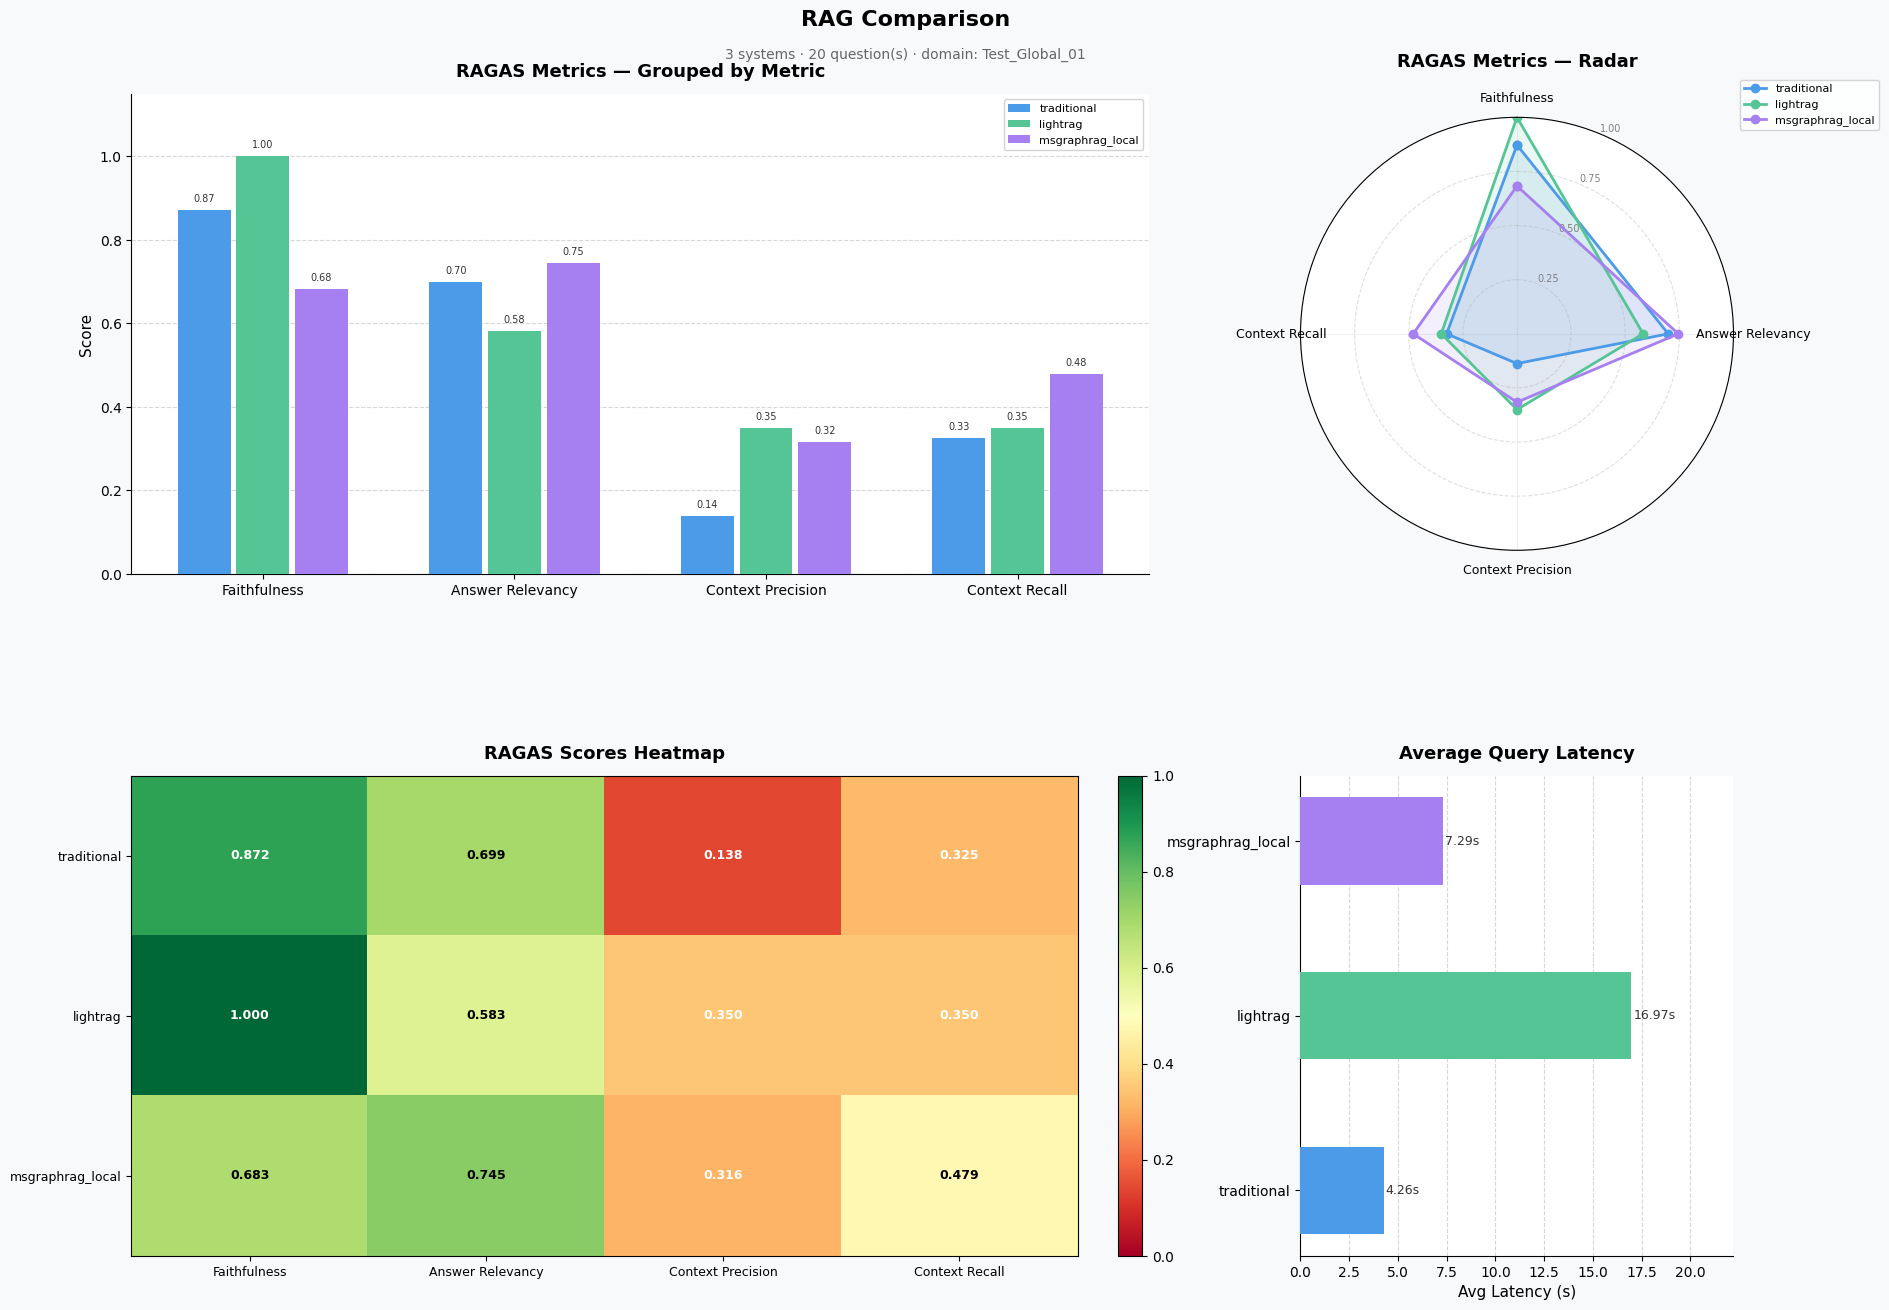

💾 Guardado en: plots/rag_comparison_comparison.png


PosixPath('plots/rag_comparison_comparison.png')

In [5]:
from src.plots.rag_visualizer import plot_rag_comparison

plot_rag_comparison(results_dir="./results", output_dir="./plots")